In [ ]:
#You initially believed that 30–50% of children in a region were malnourished. 
#After an intervention, you survey 100 children and find 25 are still affected. 
#How has this new evidence changed your belief?

In [2]:
#Step 1 – Define the Prior and Posterior

#We use a beta distribution, common in Bayesian analysis for proportions 
#(values between 0 and 1):

# Prior: Beta(5, 5)
# Posterior: Update with 25 out of 100 cases
prior <- dbeta(seq(0, 1, 0.01), 5, 5) #seq(0, 1, 0.01) is just 101 evenly spaced points betweenn 0.1. Rep all possible probability values (0%-100%)
posterior <- dbeta(seq(0, 1, 0.01), 5 + 25, 5 + 75)



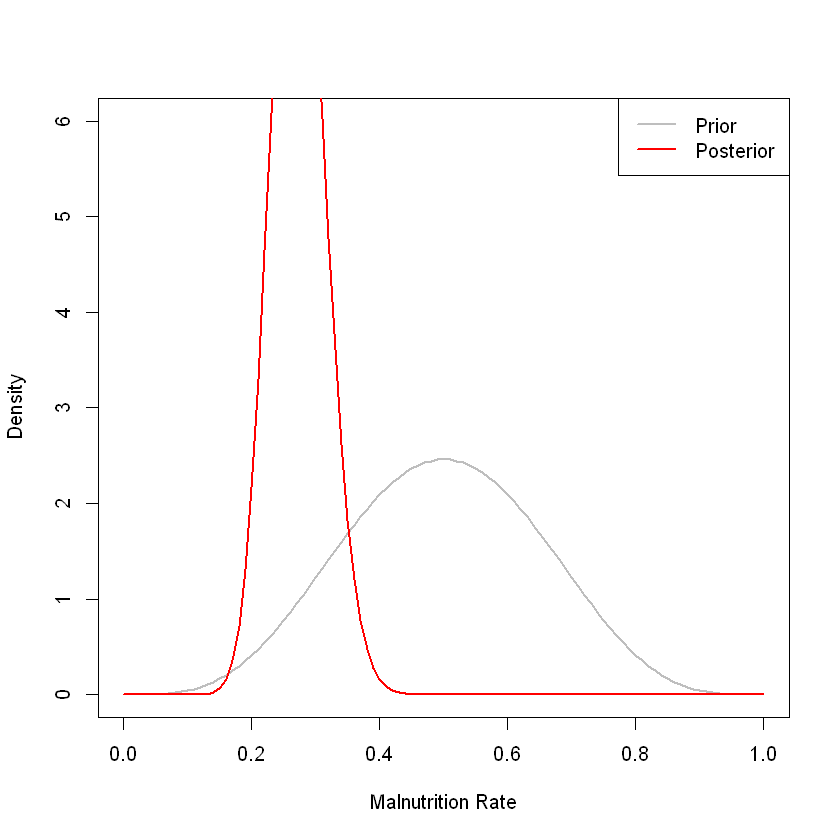

In [3]:
#Step 2 – Plot Using Base R
x <- seq(0, 1, 0.01)
plot(x, prior, type = "l", col = "gray", lwd = 2, ylim = c(0, 6),
     ylab = "Density", xlab = "Malnutrition Rate")
lines(x, posterior, col = "red", lwd = 2)
legend("topright", legend = c("Prior", "Posterior"), col = c("gray", "red"), lwd = 2)

#This shows how your belief has shifted after seeing the new data.

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"Using `size` aesthetic for lines was deprecated in
ggplot2 3.4.0.
ℹ Please use `linewidth` instead."


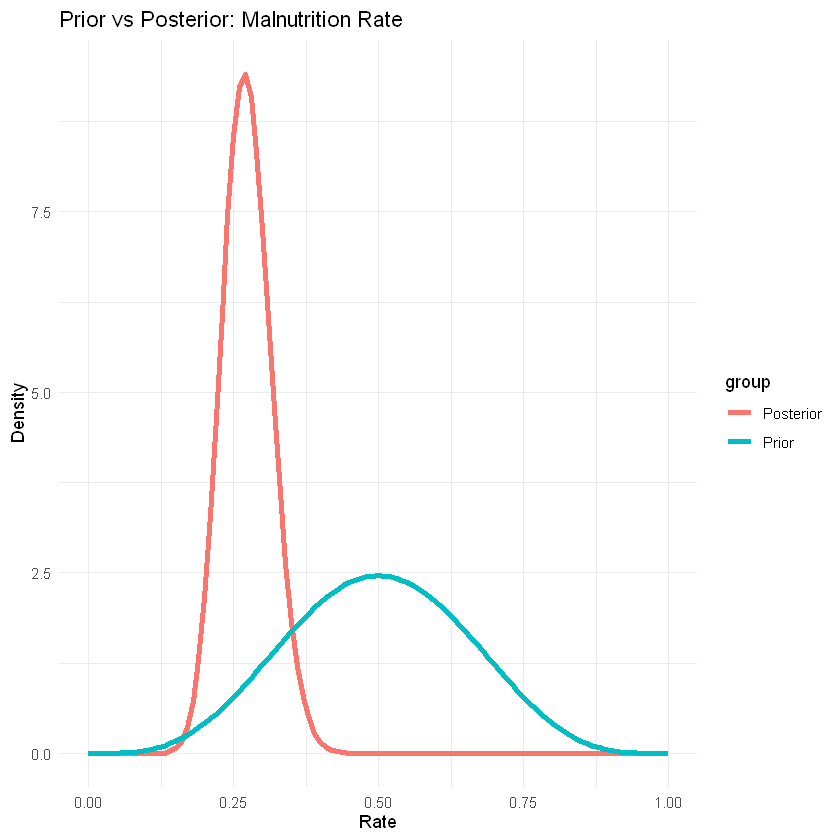

In [4]:
#Step 3 – Plot Using ggplot2
library(ggplot2)

df <- data.frame(
  x = rep(seq(0, 1, 0.01), 2),
  density = c(dbeta(seq(0, 1, 0.01), 5, 5), dbeta(seq(0, 1, 0.01), 30, 80)),
  group = rep(c("Prior", "Posterior"), each = 101)
)

ggplot(df, aes(x = x, y = density, color = group)) +
  geom_line(size = 1.5) +
  labs(title = "Prior vs Posterior: Malnutrition Rate", x = "Rate", y = "Density") +
  theme_minimal()

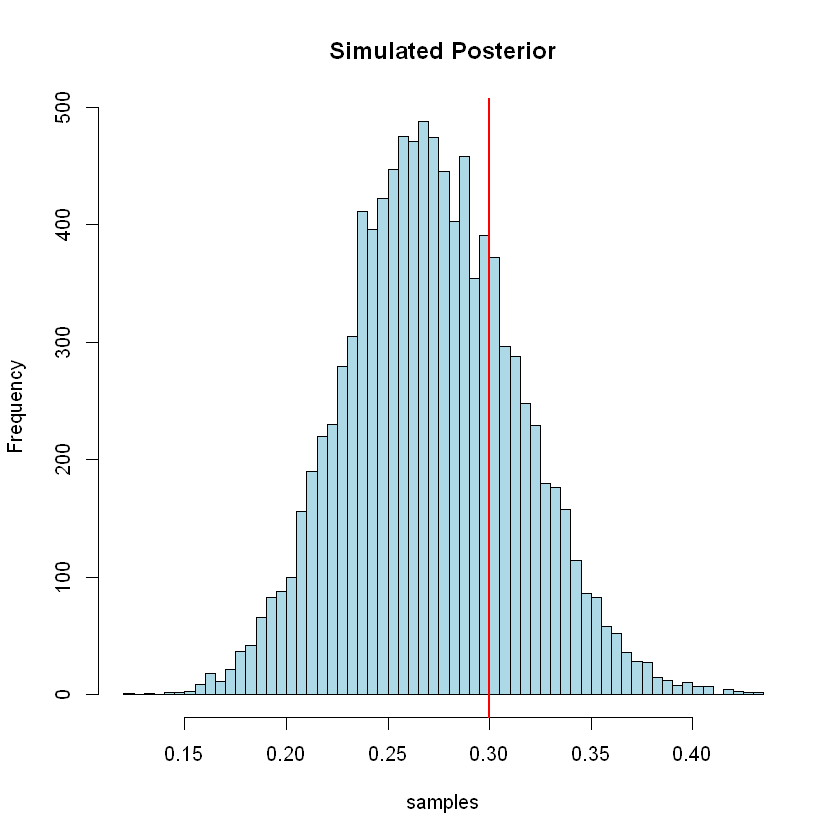

In [5]:
#Step 4 – Simulate Posterior Samples

#Visualize your belief distribution using samples:

samples <- rbeta(10000, 30, 80)
hist(samples, breaks = 50, col = "lightblue", main = "Simulated Posterior")
abline(v = 0.3, col = "red", lwd = 2)  # Optional threshold


In [9]:
#Step 5 – Make the Decision Visible
#Use mean(samples < 0.3) to calculate the chance the rate is below 30%
#Use quantile(samples, c(0.05, 0.95)) to compute a 90% credible interval

mean(samples < 0.3)               # probability rate is below 30%
quantile(samples, c(0.05, 0.95))  # 90% credible interval

[1] 0.7433

5%       95% 
0.2059404 0.3451132